In [12]:
%matplotlib inline

import sys

sys.path.append('..')

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import product
import os
import matplotlib.pyplot as plt

In [13]:
data_dir = Path(os.getenv("OODIR"))

In [14]:
ts_dir = data_dir / "ICOADS" / "OutputData"
ts_files = ts_dir.glob('timeseries_with_uncertainty_*.csv')

df = pd.concat((pd.read_csv(f, header=[0, 1], index_col=0) for f in ts_files), ignore_index=True)

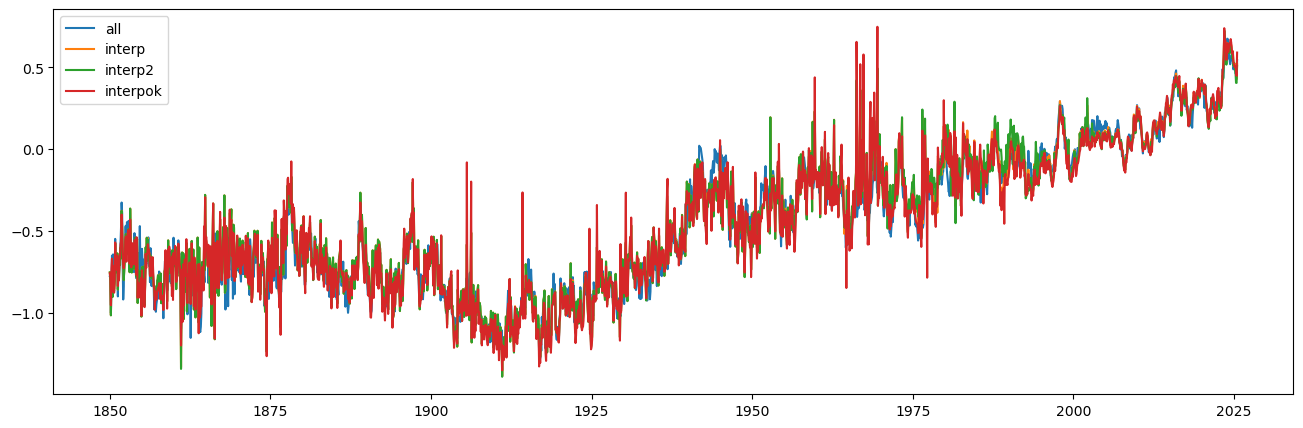

In [15]:
time = np.arange(len(df))/12. + 1850.

plt.figure()
plt.gcf().set_size_inches(16, 5)
plt.plot(time, df['all']['Global'], label='all')
plt.plot(time, df['interp']['Global'], label='interp')
plt.plot(time, df['interp2']['Global'], label='interp2')
plt.plot(time, df['interpok']['Global'], label='interpok')
plt.legend()

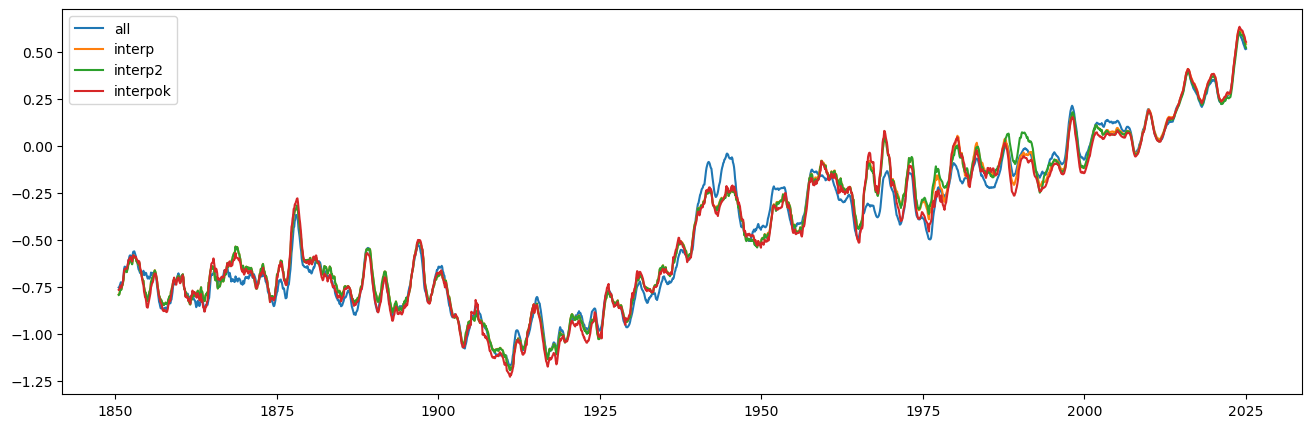

In [16]:
def ma(a, n=13):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

plt.figure()
plt.gcf().set_size_inches(16, 5)
plt.plot(ma(time), ma(df['all']['Global'].values), label='all')
plt.plot(ma(time), ma(df['interp']['Global'].values), label='interp')
plt.plot(ma(time), ma(df['interp2']['Global'].values), label='interp2')
plt.plot(ma(time), ma(df['interpok']['Global'].values), label='interpok')
plt.legend()

(-1.2, -0.0)

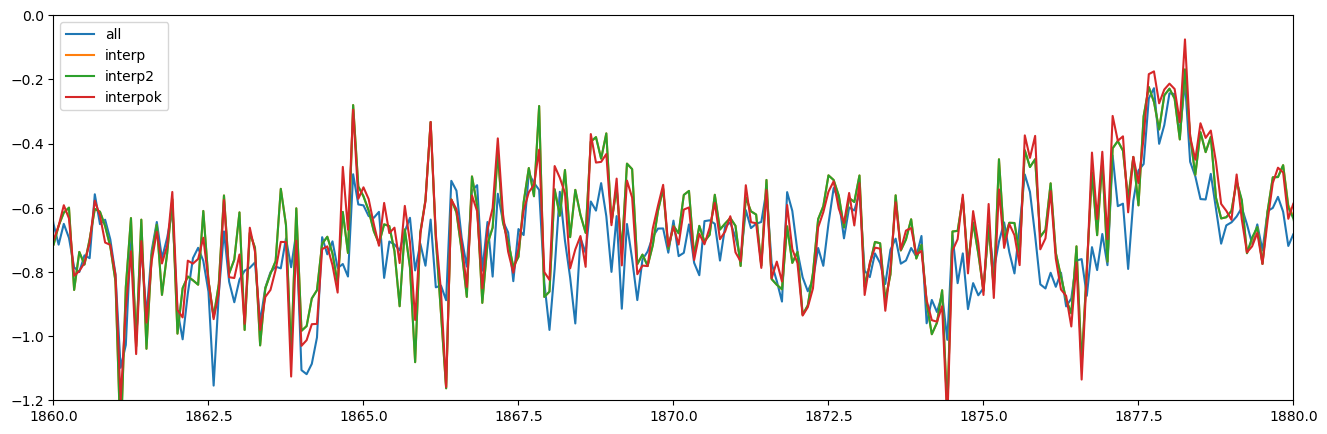

In [17]:
plt.figure()
plt.gcf().set_size_inches(16, 5)
plt.plot(time, df['all']['Global'].values, label='all')
plt.plot(time, df['interp']['Global'].values, label='interp')
plt.plot(time, df['interp2']['Global'].values, label='interp2')
plt.plot(time, df['interpok']['Global'].values, label='interpok')
plt.legend()
plt.xlim(1860,1880)
plt.ylim(-1.2, -0.0)